In [2]:
import numpy as np

# Datos de entrada

In [9]:
notas = np.array([
    1, 2, 2, 3, 3,
    3, 4, 4, 4, 4,
    5, 5, 5, 5, 5,
    5, 6, 7, 8, 9
])

# Análisis de Cuartiles

In [10]:
Q1 = np.percentile(notas, 25)
Q2 = np.percentile(notas, 50)
Q3 = np.percentile(notas, 75)

In [11]:
print("Notas ordenadas:", np.sort(notas))
print(f"Q1 = {Q1}")
print(f"Q2 (mediana) = {Q2}")
print(f"Q3 = {Q3}")

Notas ordenadas: [1 2 2 3 3 3 4 4 4 4 5 5 5 5 5 5 6 7 8 9]
Q1 = 3.0
Q2 (mediana) = 4.5
Q3 = 5.0


# Gráfico

In [13]:
import matplotlib.pyplot as plt

(array([1., 2., 3., 4., 0., 6., 1., 1., 1., 1.]),
 array([1. , 1.8, 2.6, 3.4, 4.2, 5. , 5.8, 6.6, 7.4, 8.2, 9. ]),
 <BarContainer object of 10 artists>)

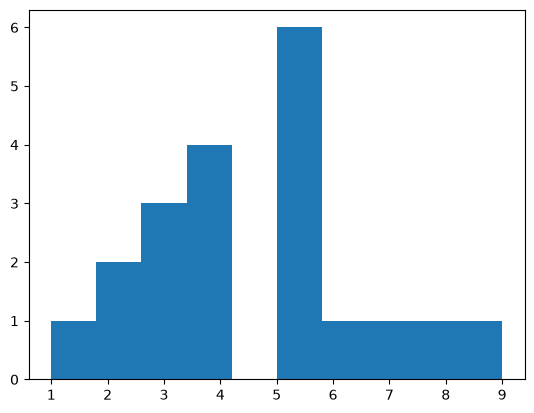

In [17]:
plt.hist(notas)

/tmp/ipykernel_2051/2115279484.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


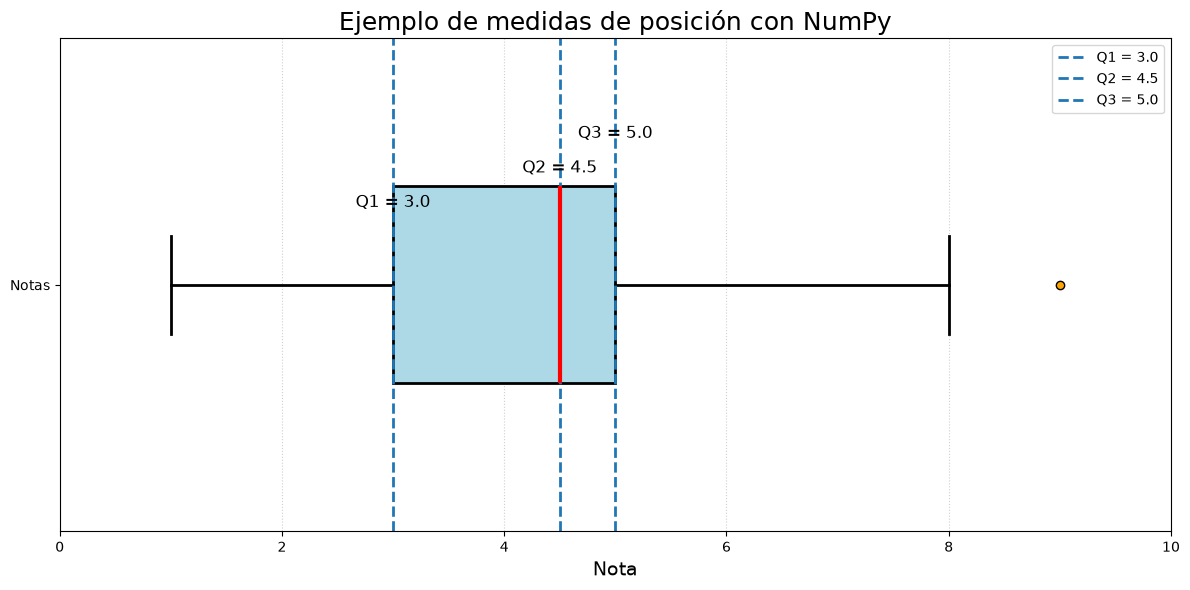

In [18]:
plt.figure(figsize=(12, 6))

# Boxplot horizontal
plt.boxplot(
    notas,
    vert=False,
    widths=0.4,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", edgecolor="black", linewidth=2),
    medianprops=dict(color="red", linewidth=3),
    whiskerprops=dict(color="black", linewidth=2),
    capprops=dict(color="black", linewidth=2),
    flierprops=dict(marker='o', markersize=6, markerfacecolor='orange', markeredgecolor='black')
)

# Líneas verticales para Q1, Q2 y Q3
plt.axvline(Q1, linestyle="--", linewidth=2, label=f"Q1 = {Q1}")
plt.axvline(Q2, linestyle="--", linewidth=2, label=f"Q2 = {Q2}")
plt.axvline(Q3, linestyle="--", linewidth=2, label=f"Q3 = {Q3}")

# Etiquetas encima de las líneas
plt.text(Q1, 1.15, f"Q1 = {Q1}", ha="center", va="bottom", fontsize=12)
plt.text(Q2, 1.22, f"Q2 = {Q2}", ha="center", va="bottom", fontsize=12)
plt.text(Q3, 1.29, f"Q3 = {Q3}", ha="center", va="bottom", fontsize=12)

# Títulos y ejes
plt.title("Ejemplo de medidas de posición con NumPy", fontsize=18)
plt.xlabel("Nota", fontsize=14)
plt.yticks([1], ["Notas"])
plt.xlim(0, 10)
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Para Jupyter, yo lo dejaría en una celda Markdown así:

### Rango intercuartílico (IQR)

El **rango intercuartílico** mide la dispersión del **50 % central de los datos**.

$$
IQR = Q_3 - Q_1
$$

Si:

$$
Q_1 = 3
$$

y

$$
Q_3 = 5
$$

entonces:

$$
IQR = 5 - 3 = 2
$$

Esto significa que el **50 % central de las notas está comprendido entre 3 y 5**, ocupando un intervalo de **2 puntos**.

- Un **IQR pequeño** indica que la parte central de los datos está bastante concentrada.
- Un **IQR grande** indica que la parte central de los datos está más dispersa.

Además, el IQR se utiliza habitualmente para detectar posibles valores atípicos:

$$
\text{Límite inferior} = Q_1 - 1.5 \cdot IQR
$$

$$
\text{Límite superior} = Q_3 + 1.5 \cdot IQR
$$

En este ejemplo:

$$
\text{Límite inferior} = 3 - 1.5 \cdot 2 = 0
$$

$$
\text{Límite superior} = 5 + 1.5 \cdot 2 = 8
$$

Por tanto, valores menores que **0** o mayores que **8** serían considerados posibles valores atípicos.

> **Idea clave:** el IQR representa la anchura ocupada por el 50 % central de los datos.


IQR ESTRECHO
Q1 = 4.37
Mediana = 5.00
Q3 = 5.63
IQR = 1.25

IQR ANCHO
Q1 = 1.46
Mediana = 5.00
Q3 = 8.54
IQR = 7.07


/tmp/ipykernel_2051/2110099425.py:52: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


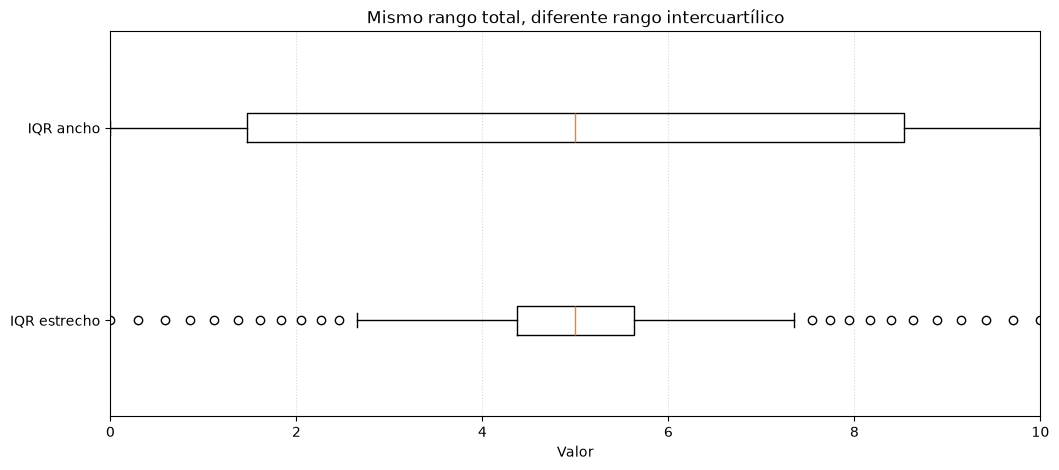

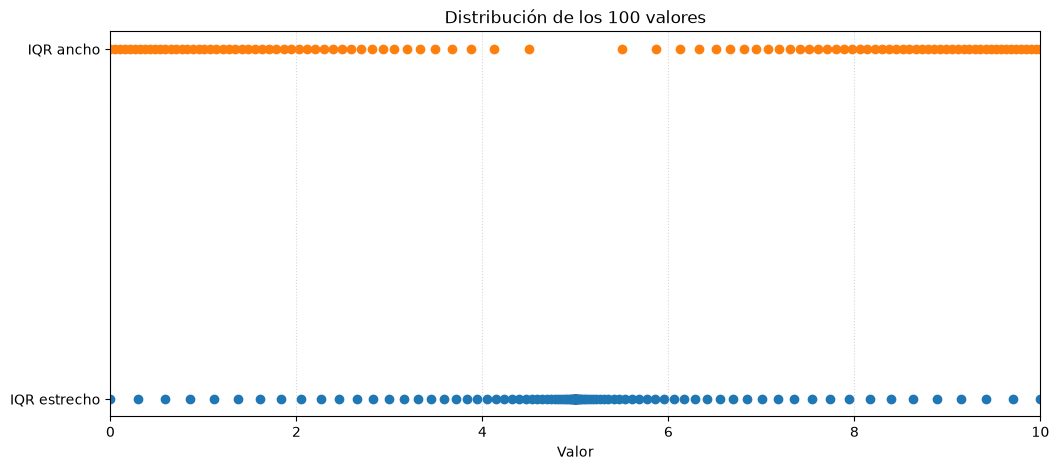

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Base común: 100 posiciones entre -1 y 1
t = np.linspace(-1, 1, 100)

# ==========================================
# 1. IQR ESTRECHO
# ==========================================
# Muchos valores concentrados alrededor de 5,
# pero seguimos teniendo datos en todo el rango 0-10
estrecho = 5 + 5 * np.sign(t) * np.abs(t)**3

# ==========================================
# 2. IQR ANCHO
# ==========================================
# Los valores están mucho más dispersos
# a lo largo de todo el rango 0-10
ancho = 5 + 5 * np.sign(t) * np.abs(t)**0.5


# ==========================================
# CÁLCULO DE CUARTILES
# ==========================================

Q1_e, Q2_e, Q3_e = np.percentile(estrecho, [25, 50, 75])
IQR_e = Q3_e - Q1_e

Q1_a, Q2_a, Q3_a = np.percentile(ancho, [25, 50, 75])
IQR_a = Q3_a - Q1_a


print("IQR ESTRECHO")
print(f"Q1 = {Q1_e:.2f}")
print(f"Mediana = {Q2_e:.2f}")
print(f"Q3 = {Q3_e:.2f}")
print(f"IQR = {IQR_e:.2f}")

print("\nIQR ANCHO")
print(f"Q1 = {Q1_a:.2f}")
print(f"Mediana = {Q2_a:.2f}")
print(f"Q3 = {Q3_a:.2f}")
print(f"IQR = {IQR_a:.2f}")


# ==========================================
# BOXPLOT
# ==========================================

plt.figure(figsize=(12, 5))

plt.boxplot(
    [estrecho, ancho],
    vert=False,
    tick_labels=["IQR estrecho", "IQR ancho"]
)

plt.xlabel("Valor")
plt.title("Mismo rango total, diferente rango intercuartílico")
plt.xlim(0, 10)
plt.grid(axis="x", linestyle=":", alpha=0.5)

plt.show()


# ==========================================
# VISUALIZAR LOS 100 DATOS
# ==========================================

plt.figure(figsize=(12, 5))

plt.scatter(estrecho, np.ones(100), label="IQR estrecho")
plt.scatter(ancho, np.ones(100) * 2, label="IQR ancho")

plt.yticks([1, 2], ["IQR estrecho", "IQR ancho"])
plt.xlabel("Valor")
plt.xlim(0, 10)
plt.title("Distribución de los 100 valores")
plt.grid(axis="x", linestyle=":", alpha=0.5)

plt.show()